In [1]:
from scipy import sparse
from ase.build import molecule
from ase.neighborlist import get_connectivity_matrix
from ase.neighborlist import natural_cutoffs
from ase.neighborlist import NeighborList
import ase
import numpy as np
from ase.io import read
from ase import Atoms
import ase.visualize
from ase.visualize.plot import plot_atoms
from cell2mol.read_write import readinfo
from cell2mol.cell_operations import frac2cart_fromparam, cart2frac
import nglview
from ase.build import molecule
from ase.neighborlist import NeighborList
import matplotlib.pyplot as plt

In [2]:
folder = "error_2"
name = "BOFFOS"
infopath = f"{folder}/{name}/{name}.info"
input_path = f"{folder}/{name}/{name}.cif"

In [7]:
labels, pos, ref_labels, ref_fracs, cellvec, cellparam = readinfo(infopath)

In [8]:
atoms = read(input_path)
cell_labels = atoms.get_chemical_symbols()
cell_pos = atoms.positions
cell_fracs = atoms.get_scaled_positions()
cell_vector = atoms.cell
# cell_parameters = atoms.cell.cellpar()
space_group = atoms.info['spacegroup']
sym_ops = space_group.get_op()

In [10]:
from cell2mol.classes import cell
newcell = cell(name, cell_labels, cell_pos, cell_vector, cellparam)
newcell.frac_coord = cell_fracs

In [11]:
debug = 2

In [12]:
newcell.get_reference_molecules(ref_labels, ref_fracs, debug=0)

#########################################
  GETREFS: Generate reference molecules  
#########################################
GETREFS: found 10 reference molecules
GETREFS: ['C6-O12-Fe', 'H24-C12-O6', 'H2-O', 'H2-O', 'H2-O', 'H24-C12-O6', 'H24-C12-O6', 'K', 'K', 'K']
GETREFS: [------------- Cell2mol MOLECULE Object --------------
 Version                      = 0.1
 Type                         = specie
 Sub-Type                     = molecule
 Number of Atoms              = 19
 Formula                      = C6-O12-Fe
 Covalent Radii Factor        = 1.3
 Metal Radii Factor           = 1.0
 Has Adjacency Matrix         = YES
 Number of Ligands            = 3
 Number of Metals             = 1
---------------------------------------------------
, ------------- Cell2mol MOLECULE Object --------------
 Version                      = 0.1
 Type                         = specie
 Sub-Type                     = molecule
 Number of Atoms              = 42
 Formula                      = H24-C12-

[------------- Cell2mol MOLECULE Object --------------
  Version                      = 0.1
  Type                         = specie
  Sub-Type                     = molecule
  Number of Atoms              = 19
  Formula                      = C6-O12-Fe
  Covalent Radii Factor        = 1.3
  Metal Radii Factor           = 1.0
  Has Adjacency Matrix         = YES
  Number of Ligands            = 3
  Number of Metals             = 1
 ---------------------------------------------------,
 ------------- Cell2mol MOLECULE Object --------------
  Version                      = 0.1
  Type                         = specie
  Sub-Type                     = molecule
  Number of Atoms              = 42
  Formula                      = H24-C12-O6
  Covalent Radii Factor        = 1.3
  Metal Radii Factor           = 1.0
  Has Adjacency Matrix         = YES
 ---------------------------------------------------,
 ------------- Cell2mol MOLECULE Object --------------
  Version                      = 0.1
 

In [14]:
from cell2mol.connectivity import compare_atoms, compare_species, compare_metals
debug = 2
unique_species = []
unique_indices = []

typelist_mols = [] # temporary variable  
typelist_ligs = [] # temporary variable
typelist_mets = [] # temporary variable

specs_found = -1
for idx, mol in enumerate(newcell.refmoleclist):
    if debug >= 2: print(f"Molecule {idx} formula={mol.formula}")
    if not mol.iscomplex:
        found = False
        for ldx, typ in enumerate(typelist_mols):   # Molecules
            issame = compare_species(mol, typ[0], debug=0)
            if issame :
                found = True ; kdx = typ[1]
                if debug >= 2: print(f"Molecule {idx} is the same with {ldx} in typelist")
        if not found:
            specs_found += 1 ; kdx = specs_found
            typelist_mols.append(list([mol, kdx]))
            unique_species.append(mol)
            if debug >= 2: print(f"New molecule found with: formula={mol.formula} and added in position {kdx}")
        unique_indices.append(kdx)
        mol.unique_index = kdx

    else:
        if not hasattr(mol,"ligands"): mol.split_complex(debug=debug)
        for jdx, lig in enumerate(mol.ligands):     # ligands
            found = False
            for ldx, typ in enumerate(typelist_ligs):
                issame = compare_species(lig, typ[0], debug=0)
                if issame :
                    found = True ; kdx = typ[1]
                    if debug >= 2: print(f"ligand {jdx} is the same with {ldx} in typelist")
            if not found:
                specs_found += 1 ; kdx = specs_found
                typelist_ligs.append(list([lig, kdx]))
                unique_species.append(lig)
                if debug >= 2: print(f"New ligand found with: formula {lig.formula} added in position {kdx}")
            unique_indices.append(kdx)
            lig.unique_index = kdx

        for jdx, met in enumerate(mol.metals):      #  metals
            found = False
            for ldx, typ in enumerate(typelist_mets):
                issame = compare_metals(met, typ[0], debug=0)
                if issame :
                    found = True ; kdx = typ[1]
                    if debug >= 2: print(f"Metal {jdx} is the same with {ldx} in typelist")
            if not found:
                specs_found += 1 ; kdx = specs_found
                typelist_mets.append(list([met, kdx]))
                unique_species.append(met)
                if debug >= 2: print(f"New Metal Center found with: labels {met.label} and added in position {kdx}")
            unique_indices.append(kdx)
            met.unique_index = kdx

Molecule 0 formula=C6-O12-Fe
New ligand found with: formula C2-O4 added in position 0
ligand 1 is the same with 0 in typelist
ligand 2 is the same with 0 in typelist
New Metal Center found with: labels Fe and added in position 1
Molecule 1 formula=H24-C12-O6
New molecule found with: formula=H24-C12-O6 and added in position 2
Molecule 2 formula=H2-O
New molecule found with: formula=H2-O and added in position 3
Molecule 3 formula=H2-O
Molecule 3 is the same with 1 in typelist
Molecule 4 formula=H2-O
Molecule 4 is the same with 1 in typelist
Molecule 5 formula=H24-C12-O6
Molecule 5 is the same with 0 in typelist
Molecule 6 formula=H24-C12-O6
Molecule 6 is the same with 0 in typelist
Molecule 7 formula=K
New molecule found with: formula=K and added in position 4
Molecule 8 formula=K
Molecule 8 is the same with 2 in typelist
Molecule 9 formula=K
Molecule 9 is the same with 2 in typelist


In [15]:
unique_species

[------------- Cell2mol LIGAND Object --------------
  Version                      = 0.1
  Type                         = specie
  Sub-Type                     = ligand
  Number of Atoms              = 6
  Formula                      = C2-O4
  Covalent Radii Factor        = 1.3
  Metal Radii Factor           = 1.0
  Has Adjacency Matrix         = YES
  Origin                       = split_complex
  Number of Groups             = 2
 ---------------------------------------------------,
 ------------- Cell2mol METAL Object --------------
  Version                      = 0.1
  Type                         = atom
  Sub-Type                     = metal
  Label                        = Fe
  Atomic Number                = 26
  Index in Molecule            = 0
  Metal Adjacency (mconnec)    = 6
  Regular Adjacencies (connec) = 6
 ----------------------------------------------------,
 ------------- Cell2mol MOLECULE Object --------------
  Version                      = 0.1
  Type             

In [16]:
unique_indices

[0, 0, 0, 1, 2, 3, 3, 3, 2, 2, 4, 4, 4]

In [22]:
for ref in newcell.refmoleclist:
    if ref.iscomplex:
        for metal in ref.metals:
            print(metal.label, metal.unique_index)
        for lig in ref.ligands:
            print(lig.formula, lig.unique_index)
    else :
        print(ref.formula, ref.unique_index)

Fe 1
C2-O4 0
C2-O4 0
C2-O4 0
H24-C12-O6 2
H2-O 3
H2-O 3
H2-O 3
H24-C12-O6 2
H24-C12-O6 2
K 4
K 4
K 4


In [23]:
selected_cs = []
for idx, spec in enumerate(unique_species):
    tmp = spec.get_possible_cs(debug=debug)
    if tmp is None: 
        print("error")
        # cell.error_empty_poscharges = True
        # return # Stopping. Empty list of possible charges received. 
    if spec.subtype != "metal":
        selected_cs.append(list([cs.corr_total_charge for cs in spec.possible_cs]))
    else :
        selected_cs.append(spec.possible_cs)   
# self.error_empty_poscharges = False
print("done")

    GET_PROTONATION_STATES: Evaluating group O with parent_indices [2]
        GET_PROTONATION_STATES: evaluating non-haptic group with index 2 and label O
    GET_PROTONATION_STATES: Evaluating group O with parent_indices [1]
        GET_PROTONATION_STATES: evaluating non-haptic group with index 1 and label O
        GET_PROTONATION_STATES:protonation_states=[------------- Cell2mol Protonation ----------------
 Status                          = True
 Labels                          = ['O', 'O', 'O', 'O', 'C', 'C']
 Type                            = Local
 Atoms added in positions        = [0 0 0 0 0 0]
 Atoms blocked (no atoms added)  = [0 1 1 0 0 0]
---------------------------------------------------
]
    POSCHARGE will try charges [0, -1, 1, -2, 2, -3, 3, -4, 4]
    POSCHARGE: charge 0 with smiles [O-][C+]([O-])[C+]([O-])[O-]
    POSCHARGE: charge 0 with smiles [O-][C+]([O-])[C+]([O-])[O-]
    POSCHARGE: charge 0 with smiles [O-][C+]([O-])[C+]([O-])[O-]
    POSCHARGE: charge 0 with

In [27]:
for spec, cs in zip(unique_species, selected_cs):
    print(spec, cs)

------------- Cell2mol LIGAND Object --------------
 Version                      = 0.1
 Type                         = specie
 Sub-Type                     = ligand
 Number of Atoms              = 6
 Formula                      = C2-O4
 Covalent Radii Factor        = 1.3
 Metal Radii Factor           = 1.0
 Has Adjacency Matrix         = YES
 Origin                       = split_complex
 Number of Groups             = 2
---------------------------------------------------
 [-2]
------------- Cell2mol METAL Object --------------
 Version                      = 0.1
 Type                         = atom
 Sub-Type                     = metal
 Label                        = Fe
 Atomic Number                = 26
 Index in Molecule            = 0
 Metal Adjacency (mconnec)    = 6
 Regular Adjacencies (connec) = 6
 Possible Charges             = [2, 3]
----------------------------------------------------
 [2, 3]
------------- Cell2mol MOLECULE Object --------------
 Version                    

In [42]:
from cell2mol.charge_assignment import balance_charge
final_charge_distribution, final_charge_list = balance_charge_test(unique_indices, unique_species, debug=debug)

BALANCE: iterlist [[-2], [2, 3], [0], [0], [1]]
BALANCE: unique_indices [0, 0, 0, 1, 2, 3, 3, 3, 2, 2, 4, 4, 4]
BALANCE: tmpdistr [(-2, 2, 0, 0, 1), (-2, 3, 0, 0, 1)]
BALANCE: alldistr added: [-2, -2, -2, 2, 0, 0, 0, 0, 0, 0, 1, 1, 1]
BALANCE: distribution=[-2, -2, -2, 2, 0, 0, 0, 0, 0, 0, 1, 1, 1]

BALANCE: alldistr added: [-2, -2, -2, 3, 0, 0, 0, 0, 0, 0, 1, 1, 1]
BALANCE: distribution=[-2, -2, -2, 2, 0, 0, 0, 0, 0, 0, 1, 1, 1]
BALANCE: distribution=[-2, -2, -2, 3, 0, 0, 0, 0, 0, 0, 1, 1, 1]



In [43]:
import itertools
def balance_charge_test(unique_indices: list, unique_species: list, debug: int=0) -> list:

    # Function to Select the Best Charge Distribution for the unique species.
    # It accepts multiple charge options for each molecule/ligand/metal (poscharge, etc...).
    # NO: It should select the best one depending on whether the final metal charge makes sense or not.
    # In some cases, can accept metal oxidation state = 0, if no other makes sense

    iserror = False
    iterlist = []
    for idx, spec in enumerate(unique_species):
        toadd = []
        if spec.subtype == "metal":
            for tch in spec.possible_cs:
                toadd.append(tch)
        else :   
            if len(spec.possible_cs) == 1:
                toadd.append(spec.possible_cs[0].corr_total_charge)
            elif len(spec.possible_cs) > 1:
                for tch in spec.possible_cs:
                    toadd.append(tch.corr_total_charge)   
            elif len(spec.possible_cs) == 0:
                iserror = True
                toadd.append("-")
        iterlist.append(toadd)

    if debug >= 2: print("BALANCE: iterlist", iterlist)
    if debug >= 2: print("BALANCE: unique_indices", unique_indices)

    if not iserror:
        tmpdistr = list(itertools.product(*iterlist))
        if debug >= 2: print("BALANCE: tmpdistr", tmpdistr)

        # Expands tmpdistr to include same species, generating alldistr:
        alldistr = []
        final_charge_list= []
        for distr in tmpdistr:
            tmp = []
            for u in unique_indices:
                tmp.append(distr[u])
            alldistr.append(tmp)
            if debug >= 2: print("BALANCE: alldistr added:", tmp)

            final_charge_distribution = []
            for idx, d in enumerate(alldistr):
                if debug >= 2: print(f"BALANCE: distribution={d}")
                final_charge = np.sum(d)
                if final_charge == 0:
                    final_charge_distribution.append(d)
                    final_charge_list.append(distr)
            if debug >= 2: print("")
    elif iserror:
        if debug >= 1: print("Error found in BALANCE: one species has no possible charges")
        final_charge_distribution = []

    return final_charge_distribution, final_charge_list

In [44]:
final_charge_distribution

[[-2, -2, -2, 3, 0, 0, 0, 0, 0, 0, 1, 1, 1]]

In [45]:
final_charge_list

[(-2, 3, 0, 0, 1)]

In [65]:
from IPython.display import display
from rdkit.Chem.Draw import IPythonConsole
IPythonConsole.drawOptions.addAtomIndices = True
IPythonConsole.molSize = 300,300
from rdkit import Chem
from cell2mol.connectivity import create_bonds_spicie

0
CREATE_bonds_specie: specie.formula='C2-O4', specie.subtype='ligand'
	Number of atoms in ligand object and RDKit object are equal: 6 6
	idx=0 O Number of bonds : 1
	BOND CREATED 0 0 4 2.0 O C
	BONDS [('O', 'C', 2.0, 1.219)]
	idx=1 O Number of bonds : 1
	BOND CREATED 1 1 4 1.0 O C
	BONDS [('O', 'C', 1.0, 1.28)]
	idx=2 O Number of bonds : 1
	BOND CREATED 2 2 5 2.0 O C
	BONDS [('O', 'C', 2.0, 1.273)]
	idx=3 O Number of bonds : 1
	BOND CREATED 3 3 5 1.0 O C
	BONDS [('O', 'C', 1.0, 1.213)]
	idx=4 C Number of bonds : 3
	BOND CREATED 4 4 0 2.0 C O
	BOND CREATED 4 4 1 1.0 C O
	BOND CREATED 4 4 5 1.0 C C
	BONDS [('C', 'O', 2.0, 1.219), ('C', 'O', 1.0, 1.28), ('C', 'C', 1.0, 1.554)]
	idx=5 C Number of bonds : 3
	BOND CREATED 5 5 2 2.0 C O
	BOND CREATED 5 5 3 1.0 C O
	BOND CREATED 5 5 4 1.0 C C
	BONDS [('C', 'O', 2.0, 1.273), ('C', 'O', 1.0, 1.213), ('C', 'C', 1.0, 1.554)]
------------- Cell2mol Charge State ---------------
 Status                          = True
 Smiles                        

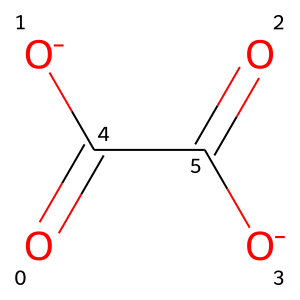

1
2
CREATE_bonds_specie: specie.formula='H24-C12-O6', specie.subtype='molecule'
	Number of atoms in molecule object and RDKit object are equal: 42 42
	idx=0 O Number of bonds : 2
	BOND CREATED 0 0 6 1.0 O C
	BOND CREATED 0 0 39 1.0 O C
	BONDS [('O', 'C', 1.0, 1.417), ('O', 'C', 1.0, 1.423)]
	idx=1 O Number of bonds : 2
	BOND CREATED 1 1 9 1.0 O C
	BOND CREATED 1 1 12 1.0 O C
	BONDS [('O', 'C', 1.0, 1.423), ('O', 'C', 1.0, 1.419)]
	idx=2 O Number of bonds : 2
	BOND CREATED 2 2 15 1.0 O C
	BOND CREATED 2 2 18 1.0 O C
	BONDS [('O', 'C', 1.0, 1.411), ('O', 'C', 1.0, 1.415)]
	idx=3 O Number of bonds : 2
	BOND CREATED 3 3 21 1.0 O C
	BOND CREATED 3 3 24 1.0 O C
	BONDS [('O', 'C', 1.0, 1.423), ('O', 'C', 1.0, 1.416)]
	idx=4 O Number of bonds : 2
	BOND CREATED 4 4 27 1.0 O C
	BOND CREATED 4 4 30 1.0 O C
	BONDS [('O', 'C', 1.0, 1.4), ('O', 'C', 1.0, 1.409)]
	idx=5 O Number of bonds : 2
	BOND CREATED 5 5 33 1.0 O C
	BOND CREATED 5 5 36 1.0 O C
	BONDS [('O', 'C', 1.0, 1.436), ('O', 'C', 1.0, 1.41

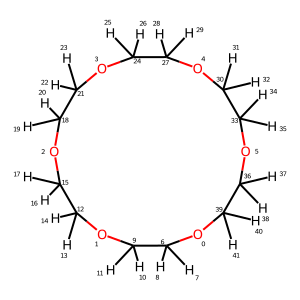

3
CREATE_bonds_specie: specie.formula='H2-O', specie.subtype='molecule'
	Number of atoms in molecule object and RDKit object are equal: 3 3
	idx=0 O Number of bonds : 2
	BOND CREATED 0 0 1 1.0 O H
	BOND CREATED 0 0 2 1.0 O H
	BONDS [('O', 'H', 1.0, 0.867), ('O', 'H', 1.0, 0.859)]
	idx=1 H Number of bonds : 1
	BOND CREATED 1 1 0 1.0 H O
	BONDS [('H', 'O', 1.0, 0.867)]
	idx=2 H Number of bonds : 1
	BOND CREATED 2 2 0 1.0 H O
	BONDS [('H', 'O', 1.0, 0.859)]
------------- Cell2mol Charge State ---------------
 Status                          = True
 Smiles                          = [H]O[H]
 Charge Tried                    = 0
 Uncorrected Total Charge        = 0
 Corrected Total Charge          = 0
 Corrected Absolute Total Charge = 0
 Corrected Is Zwitterion?        = False
---------------------------------------------------

[H]O[H]


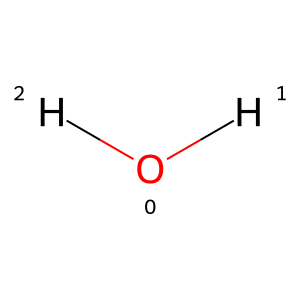

4
CREATE_bonds_specie: specie.formula='K', specie.subtype='molecule'
	Number of atoms in molecule object and RDKit object are equal: 1 1
	idx=0 K Number of bonds : 0
	NO BONDS CREATED for K due to no bonds in molecule RDKit object
------------- Cell2mol Charge State ---------------
 Status                          = True
 Smiles                          = [K+]
 Charge Tried                    = 1
 Uncorrected Total Charge        = 1
 Corrected Total Charge          = 1
 Corrected Absolute Total Charge = 1
 Corrected Is Zwitterion?        = False
---------------------------------------------------

[K+]


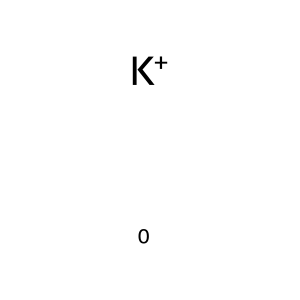

In [70]:
for specie, final_charge in zip(unique_species, final_charge_list[0]):
    print(specie.unique_index)
    if (specie.subtype == "molecule" and specie.iscomplex == False) or (specie.subtype == "ligand"):
        charge_list = [cs.corr_total_charge for cs in specie.possible_cs]
        idx = charge_list.index(final_charge)
        cs = specie.possible_cs[idx]
        specie.set_charges(cs.corr_total_charge, cs.corr_atom_charges, cs.smiles, cs.rdkit_obj)

    else :
        charge_list = specie.possible_cs   
        idx = charge_list.index(final_charge)
        cs = specie.possible_cs[idx]
        specie.set_charge(cs)     
        
    if (specie.subtype == "molecule" and specie.iscomplex == False) or (specie.subtype == "ligand"):
        create_bonds_spicie(specie, debug=2)
        print(cs)
        # print(cs.rdkit_obj)
        print(Chem.MolToSmiles(cs.rdkit_obj, canonical=True))
        display(cs.rdkit_obj)
    # print(final_charge)
    # print(spec.possible_cs)

In [ ]:
# How to match unique_specie in reference molecules to all the molecules within the unit cell?
# What is the easiest way?
for ref in newcell.refmoleclist:
    